# Linear Regression

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/konstantin-schekotihin/dl_course/blob/master/AI-ML/02_regression.ipynb)


In [1]:
# Setup & configuration (skip in presentation slides)
%matplotlib inline
from IPython.display import Markdown, display
import numpy as np
import pandas as pd
import statsmodels.api as sm
from ipywidgets import interact
from sklearn.linear_model import LinearRegression

# Load course helper utilities (local file or direct GitHub fetch for standalone Colab)
try:
    import helpers as hp
except ImportError:
    import urllib.request
    _url = "https://raw.githubusercontent.com/konstantin-schekotihin/dl_course/master/AI-ML/helpers.py"
    urllib.request.urlretrieve(_url, "helpers.py")
    import helpers as hp


## 1. Problem Formulation & Foundations
- **Goal**: Predict a continuous target variable $t \in \mathbb{R}$ given an input feature vector $\mathbf{x} = (x_1, \dots, x_D)^\mathrm{T} \in \mathbb{R}^D$.
- Historical origin: Francis Galton (1886) studied heredity and observed that offspring heights *regressed* toward the population mean.
- Today, regression is the core paradigm for modeling continuous dependencies between variables.


### The Data Generating Process

- We assume the ground-truth target $t \in \mathbb{R}$ is generated by a deterministic function $f(\mathbf{x})$ corrupted by additive stochastic noise $\epsilon$:

$$
t = f(\mathbf{x}) + \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, \sigma^2)
$$

- **Gaussian Noise ($\mathcal{N}(0, \sigma^2)$)**: $\epsilon$ follows a normal distribution with zero mean and variance $\sigma^2$, capturing measurement noise and unobserved factors (**aleatoric uncertainty**).
- **Learning Objective**: Find a model $y(\mathbf{x}, \mathbf{w})$ that approximates $f(\mathbf{x})$ given training samples $\mathcal{D} = \{(\mathbf{x}_n, t_n)\}_{n=1}^N$.


### Motivating Case Study: The Advertising Benchmark
- Advertising data set: sales of some product in 200 different markets, along with advertising budgets for the product in each of those
markets for three different media: TV, radio, and newspaper.
  + *TV*, *newspaper* and *radio* are independent variables, aka predictors, covariates, input variables, or features
  + *sales* is a dependent variable that we want to predict, aka response, variate, output variable, or labels


In [2]:
# Load Advertising dataset (supports local cache and Colab remote stream)
adv = pd.read_csv(hp.get_data_path("Advertising.csv"))
if "Unnamed: 0" in adv.columns:
    adv = adv.drop(columns=["Unnamed: 0"])
adv.head(5)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
adv.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


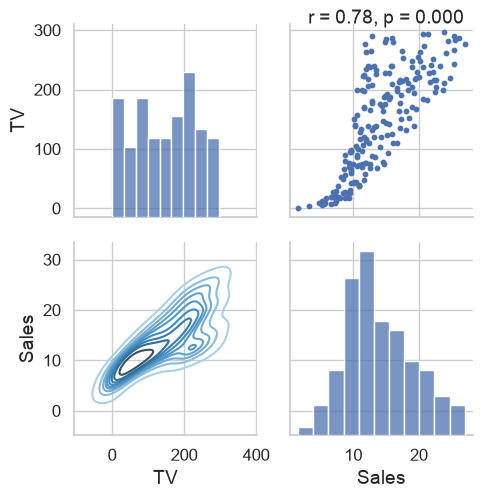

In [4]:
hp.plot_pairgrid(adv[["TV", "Sales"]])

### Central Research Questions

- If we invest more in advertisement, will it make any difference for the sales? Is there any relationship between them?
- If the relationship exists: is it positive or negative? How strong is it?
- Is the relationship linear?
- Which of the three media TV, radio or newspapers contribute to sales?
- Are there relations between the advertising media? 
    * For example, advertisement on TV and radio has stronger influence on sales, than only on TV
- How accurately can we predict future sales?

## 2. Simple Linear Regression

- Model with a single input feature $x$ and scalar parameters $\mathbf{w} = (w_0, w_1)^\mathrm{T}$:

$$
y(x, \mathbf{w}) = w_0 + w_1 x
$$

  - $w_0$: **bias / intercept** (predicted value when $x = 0$)
  - $w_1$: **weight / slope** (expected change in $t$ per unit increase in $x$)

- Example (Advertising dataset):

$$
\text{Sales} \approx w_0 + w_1 \cdot \text{TV}
$$


### Parameter Estimation & Predictions

- Given parameter estimates $\hat{w}_0$ and $\hat{w}_1$, predictions are computed as:

$$
\hat{t}_n = y(x_n, \hat{\mathbf{w}}) = \hat{w}_0 + \hat{w}_1 x_n
$$

- **Matrix Formulation**: $\hat{\mathbf{t}} = \mathbf{X}\hat{\mathbf{w}}$, where $\mathbf{X} \in \mathbb{R}^{N \times 2}$ incorporates a constant dummy column $\mathbf{1}$ for the intercept $w_0$:

$$
\hat{\mathbf{t}} = \mathbf{X}\hat{\mathbf{w}} =
\begin{bmatrix}
    1 & x_1 \\
    1 & x_2 \\
    \vdots & \vdots \\
    1 & x_N
\end{bmatrix}
\begin{bmatrix}
    \hat{w}_0 \\
    \hat{w}_1
\end{bmatrix}
$$


In [5]:
def compute_regression_metrics(resp, est):
    """Compute standard sum-of-squares and linear regression error metrics."""
    rss = np.sum((resp - est) ** 2)
    tss = np.sum((resp - np.mean(resp)) ** 2)
    ess = tss - rss
    mse = rss / len(resp)
    mae = np.mean(np.abs(resp - est))
    return {"TSS": tss, "RSS": rss, "ESS": ess, "MSE": mse, "MAE": mae}

def residuals(w0=0, w1=0, l=0, u=200, show=False):
    f = lambda x: w0 + w1 * x
    tv = adv.TV[l:u].to_numpy()
    sales = adv.Sales[l:u].to_numpy()
    est = f(tv)
    if show:
        m = compute_regression_metrics(sales, est)
        display(Markdown(rf"$\mathrm{{TSS}} = {m['TSS']:.3f}$ (total sum of squares)"))
        display(Markdown(rf"$\mathrm{{RSS}} = {m['RSS']:.3f}$ (residual sum of squares)"))
        display(Markdown(rf"$\mathrm{{ESS}} = \mathrm{{TSS}} - \mathrm{{RSS}} = {m['ESS']:.3f}$ (explained sum of squares)"))
        display(Markdown(rf"$\mathrm{{MSE}} = {m['MSE']:.3f}$ (mean squared error)"))
        display(Markdown(rf"$\mathrm{{MAE}} = {m['MAE']:.3f}$ (mean absolute error)"))
    hp.plot_residuals(f, tv, sales, show=False)


In [6]:
interact(residuals, w0=(0,10,1), w1=(0.01,0.1,0.01), l=(0,200,10), u=(0,200,10));

interactive(children=(IntSlider(value=0, description='w0', max=10), FloatSlider(value=0.01, description='w1', …

### Error Metrics & Sum-of-Squares Objective

- **Total Sum of Squares (TSS)** (target variance around mean $\bar{t} = \frac{1}{N}\sum_n t_n$):

$$
\mathrm{TSS} = \sum_{n=1}^{N} (t_n - \bar{t})^2 = \|\mathbf{t} - \bar{t}\mathbf{1}\|^2, \quad \mathbf{1} = (1, \dots, 1)^\mathrm{T} \in \mathbb{R}^N
$$

- **Residual Sum of Squares (RSS)** (unexplained prediction variance):

$$
\mathrm{RSS} = \sum_{n=1}^{N} (t_n - \hat{t}_n)^2 = \|\mathbf{t} - \mathbf{X}\mathbf{w}\|^2
$$

- **Mean Squared Error (MSE)** and **Root Mean Squared Error (RMSE)**:

$$
\mathrm{MSE} = \frac{1}{N} \mathrm{RSS}, \quad \mathrm{RMSE} = \sqrt{\mathrm{MSE}}
$$

- **Mean Absolute Error (MAE)**: $\mathrm{MAE} = \frac{1}{N} \sum_{n=1}^{N} |t_n - \hat{t}_n| = \frac{1}{N} \|\mathbf{t} - \hat{\mathbf{t}}\|_1$.


In [7]:
interact(residuals, w0=(0,10,1), w1=(0.01,0.1,0.01), l=(0,200,10), u=(0,200,10), show=True);

interactive(children=(IntSlider(value=0, description='w0', max=10), FloatSlider(value=0.01, description='w1', …

### Closed-Form Solution: Ordinary Least Squares (OLS)

- **Residual** for observation $n$: $e_n = t_n - \hat{t}_n = t_n - (w_0 + w_1 x_n)$.
- **Sum-of-Squares Objective Function** $E(\mathbf{w})$:

$$
E(\mathbf{w}) = \frac{1}{2} \sum_{n=1}^{N} (y(x_n, \mathbf{w}) - t_n)^2
$$

- Minimizing $E(\mathbf{w})$ by setting gradients to zero yields the closed-form OLS estimators:

$$
\hat{w}_1 = \frac{\sum_{n=1}^{N} (x_n - \bar{x})(t_n - \bar{t})}{\sum_{n=1}^{N} (x_n - \bar{x})^2}, \quad \hat{w}_0 = \bar{t} - \hat{w}_1 \bar{x}
$$


### Empirical OLS Fit: Sales vs. TV Budget

- Red line shows the least squares fit for the regression of $\text{Sales}$ onto $\text{TV}$.
- Blue segments represent residuals between input observations (blue dots) and the least squares line, which approximates the underlying regression line ($e_n = t_n - \hat{t}_n$).


Parameters: w_0 = 7.032593549127695, w_1 = [0.04753664]


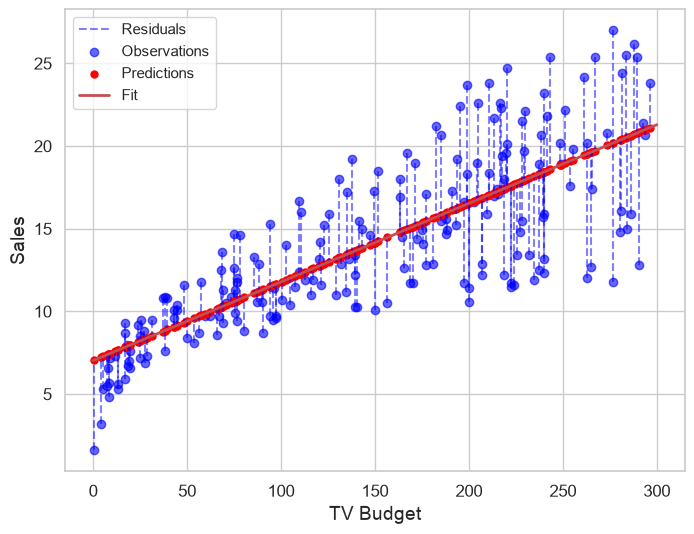

In [8]:
from sklearn.linear_model import LinearRegression

tv = adv.TV[0:200].to_numpy()
sales = adv.Sales[0:200].to_numpy()
lin_model = LinearRegression().fit(tv.reshape(-1,1), sales)
display(Markdown(rf"Parameters: $w_0 = {lin_model.intercept_:.4f}, w_1 = {lin_model.coef_[0]:.4f}$"))
hp.plot_residuals(lin_model.predict, tv, sales)


## 3. Statistical Inference & Evaluation of Fit

> 💡 **Core Objective:** Quantify the extent to which the fitted regression model explains the variance in the target data.


In [9]:
lm = sm.OLS(adv.Sales, sm.add_constant(adv.TV))
print(lm.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.47e-42
Time:                        11:46:50   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

### Residual Standard Error (RSE)

- **Residual Standard Error (RSE)** estimates the standard deviation $\sigma$ of the noise $\epsilon$:

$$
\mathrm{RSE} = \hat{\sigma} = \sqrt{\frac{\mathrm{RSS}}{N - D - 1}}
$$

- **Degrees of Freedom ($N - D - 1$)**: For simple regression with $D = 1$ predictor, degrees of freedom are $N - 2$.
- Measures the typical deviation between true observations and the fitted regression line in units of the target $t$.


### Standard Errors of Parameter Estimates

- The **Standard Error (SE)** quantifies the sampling variance of estimates across repeated samples of size $N$:

$$
\mathrm{SE}(\hat{w}_1)^2 = \frac{\sigma^2}{\sum_{n=1}^{N} (x_n - \bar{x})^2}, \quad \mathrm{SE}(\hat{w}_0)^2 = \sigma^2 \left[ \frac{1}{N} + \frac{\bar{x}^2}{\sum_{n=1}^{N} (x_n - \bar{x})^2} \right]
$$

- **Noise Variance $\sigma^2$**: In practice, true $\sigma^2$ is unknown and estimated by the Residual Standard Error ($\mathrm{RSE}^2 = \hat{\sigma}^2$).
- **95% Confidence Interval**: $\hat{w}_j \pm 2 \cdot \mathrm{SE}(\hat{w}_j)$.


- In the advertisement example: 
  - estimates of coefficients $w_0 = 7.0326$ (const) and $w_1 = 0.0475$ (TV) are very large relative to their standard errors, $0.458$ and $0.003$, resp.
  - the interval $[6.130, 7.935]$ with 95% comprises the real value of $w_0$ and the interval $[0.042, 0.053]$ - the real value of $w_1$

### Hypothesis Testing for Coefficients ($t$-Statistic)

- We test whether feature $x$ has a statistically significant linear association with $t$:
  - $H_0$: $w_1 = 0$ (no relationship between predictor and target).
  - $H_1$: $w_1 \neq 0$ (significant linear relationship).
- **$t$-Statistic**:

$$
t = \frac{\hat{w}_1 - 0}{\mathrm{SE}(\hat{w}_1)}
$$

- Measures how many standard deviations $\hat{w}_1$ is away from zero under $H_0$.

### Statistical Significance & $p$-Values

- **Connecting $t$-Statistic to $p$-Value**:
  - Under $H_0: w_1 = 0$, test statistic $t$ follows Student's $t$-distribution with $\nu = N - 2$ degrees of freedom ($t \sim t_{\nu}$).
  - The **$p$-value** is the two-tailed probability of observing a test statistic at least as extreme as $|t|$:<br>
$$
p\text{-value} = 2 \left(1 - F_{t_{\nu}}(|t|)\right)
$$ 
<br>
where $F_{t_{\nu}}$ is the CDF of $t_{\nu}$, and $\nu = N - 2$ (estimating $\hat{w}_0$ and $\hat{w}_1$ imposes 2 constraints on $N$ observations).
- **Inference & Decision Rule**: Reject $H_0$ if $p\text{-value} \le \alpha$ (typically $0.05$). For TV budget, $p < 0.0001$, confirming strong statistical significance.


### The $R^2$ Statistic (Coefficient of Determination)

- $R^2$ measures the **proportion of target variance explained** by the model:

$$
R^2 = 1 - \frac{\mathrm{RSS}}{\mathrm{TSS}} = \frac{\mathrm{TSS} - \mathrm{RSS}}{\mathrm{TSS}}
$$

- Dimensionless metric scaled in $[0, 1]$ (can be negative on poor test data):
  - $R^2 = 1$: Perfect fit (model explains 100% of variance).
  - $R^2 = 0$: Model performs no better than the sample mean $\bar{t}$.
- For simple linear regression, $R^2$ is exactly the square of the sample Pearson correlation coefficient: $R^2 = r_{xt}^2$.


## 4. Non-Linear Extensions: Polynomial Regression

- We can extend linear regression to non-linear relationships by creating polynomial basis functions:

$$
y(x, \mathbf{w}) = w_0 + w_1 x + w_2 x^2 + w_3 x^3 = \sum_{j=0}^{M} w_j \phi_j(x)
$$

> 💡 **Key Insight:** Even though the function is non-linear in the input feature $x$, the model remains **linear in the parameters $\mathbf{w}$**! Consequently, the standard Ordinary Least Squares (OLS) normal equations still apply in closed form to the transformed design matrix $\boldsymbol{\Phi}$.


## 5. Multiple Linear Regression

- Let's fit linear regression for individual predictors

### Multivariate Case Study: Feature Synergies & Collinearity

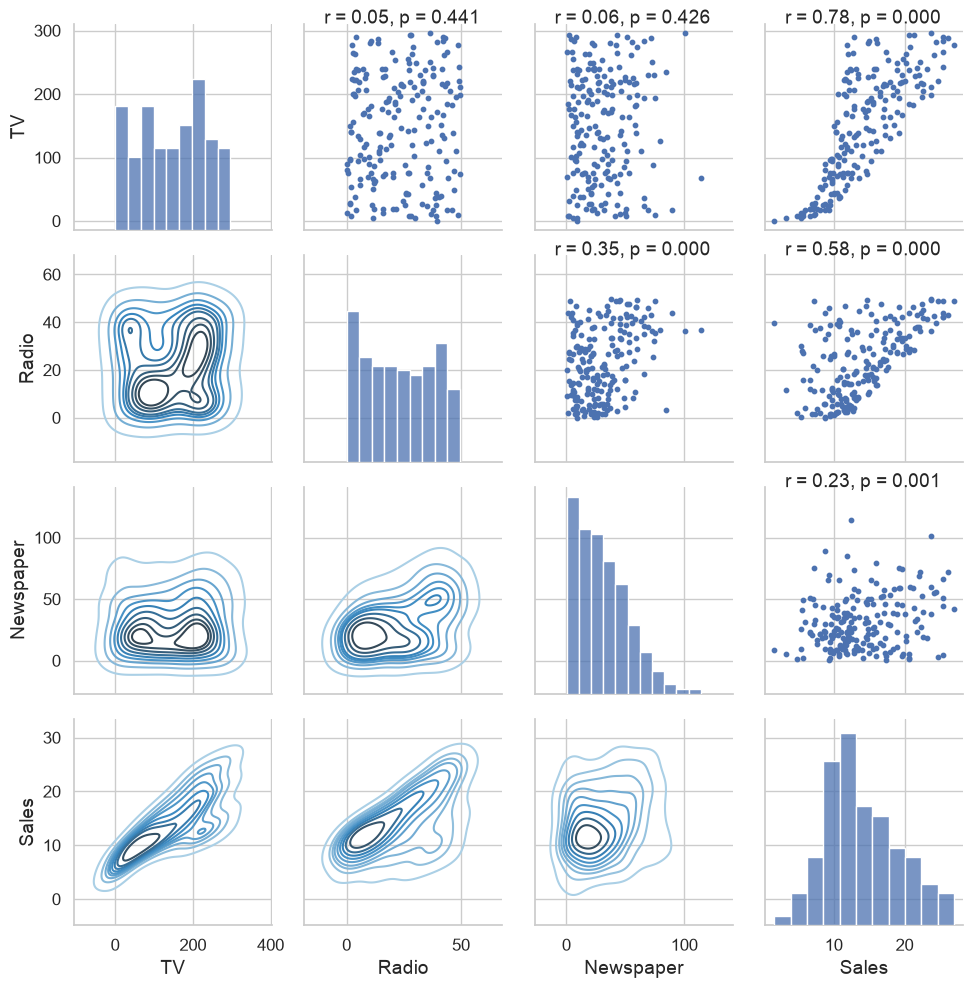

In [10]:
hp.plot_pairgrid(adv)

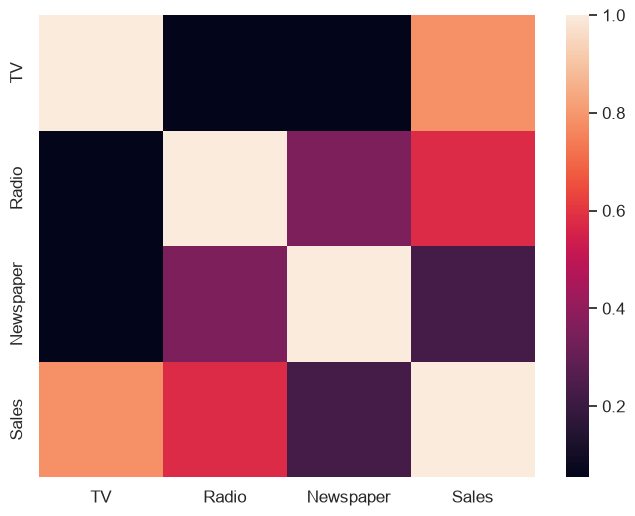

In [11]:
hp.plot_correlation_matrix(adv.corr(), title="Advertising Feature Correlations")

In [12]:
lm = LinearRegression().fit(adv.Radio.values.reshape(-1,1), adv.Sales)
print("Radio: {}".format(lm.coef_))
lm = LinearRegression().fit(adv.TV.values.reshape(-1,1), adv.Sales)
print("TV: {}".format(lm.coef_))
lm = LinearRegression().fit(adv.Newspaper.values.reshape(-1,1), adv.Sales)
print("Newspaper: {}".format(lm.coef_))

Radio: [0.20249578]
TV: [0.04753664]
Newspaper: [0.0546931]


- Increase of advertisement budget by 1000 increases sales by appr.
    + Radio:  203 items
    + TV: 47 items
    + Newspaper: 55 items
- Are there any synergies between these features?

### Matrix Formulation: $\mathbf{t} = \mathbf{X}\mathbf{w} + \boldsymbol{\epsilon}$

- With $D$ input features, multiple linear regression predicts $y(\mathbf{x}, \mathbf{w}) = w_0 + \sum_{j=1}^D w_j x_j = \mathbf{w}^\mathrm{T}\mathbf{x}$, where $\mathbf{x} = (1, x_1, \dots, x_D)^\mathrm{T}$ incorporates dummy intercept $x_0 = 1$.

- **Matrix Representation**: $\mathbf{t} = \mathbf{X}\mathbf{w} + \boldsymbol{\epsilon}$, where model predictions are $\hat{\mathbf{t}} = \mathbf{X}\mathbf{w}$.
- **Closed-Form Normal Equations** (minimizing $\mathrm{RSS}(\mathbf{w}) = \|\mathbf{t} - \mathbf{X}\mathbf{w}\|^2$):

$$
\mathbf{w}^\star = (\mathbf{X}^\mathrm{T}\mathbf{X})^{-1}\mathbf{X}^\mathrm{T}\mathbf{t}
$$


In [13]:
X = adv.iloc[:,[0,1]]
lm = sm.OLS(adv.Sales, sm.add_constant(X))
print(lm.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           4.83e-98
Time:                        11:46:51   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9211      0.294      9.919      0.0

In [14]:
# Influence of the scaling on the coefficients

X = adv.iloc[:,[0,1]]
X = (X - X.mean())/X.std()
lm = sm.OLS(adv.Sales, sm.add_constant(X))
print(lm.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           4.83e-98
Time:                        11:46:51   Log-Likelihood:                -386.20
No. Observations:                 200   AIC:                             778.4
Df Residuals:                     197   BIC:                             788.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         14.0225      0.119    117.945      0.0

### Multivariate Model Diagnostics

- Coefficients for $\text{TV}$ and $\text{Radio}$ remain statistically significant and positive.
- The coefficient for $\text{Newspaper}$ drops from $0.055$ to near zero with a non-significant $p\text{-value}$, indicating no substantial direct linear contribution when controlling for $\text{TV}$ and $\text{Radio}$.
- Moderate collinearity ($r_{\text{Radio}, \text{Newspaper}} = 0.35$) means newspaper spending shared variance with radio spending, which confounded the simple bivariate regression.


### Overall Model Significance: The $F$-Statistic

- Tests whether **any** predictor feature has a non-zero association with $t$:
  - $H_0$: $w_1 = w_2 = \dots = w_D = 0$
  - $H_1$: at least one $w_j \neq 0$

- **$F$-Statistic**:

$$
F = \frac{(\mathrm{TSS} - \mathrm{RSS})/D}{\mathrm{RSS}/(N - D - 1)}
$$

- When $H_0$ is true, $F \approx 1$; when predictors are informative, $F \gg 1$.

## 6. Model Selection & Feature Search

### The Model Complexity Dilemma: Training vs. Test Error

- **Monotonic Decrease of Training Error**: Adding predictors to a linear model *always* decreases (or maintains) training $\mathrm{RSS}$ and inflates raw $R^2$:
  - Extra parameters give the optimizer degrees of freedom to fit sample-specific random noise.
- **Overfitting & Generalization Gap**: Beyond the optimal subset, test error ($\mathrm{RSS}_{\mathrm{test}}$) increases due to higher estimator variance.
- **Two Paradigms for Model Selection**:
  1. **Empirical Validation**: Directly estimate test error via holdout validation or $k$-fold cross-validation.
  2. **Analytical Penalization**: Adjust training error mathematically by penalizing model size $D$.


### Complexity-Penalized Criteria: AIC, BIC & Adjusted $R^2$

- **Akaike Information Criterion (AIC)**:
  - Rooted in information theory; estimates relative Kullback-Leibler divergence from the true data-generating distribution.
  - **Smallest preferred**: Minimizes expected information loss by balancing empirical loss with a $2D$ parameter penalty.
- **Bayesian Information Criterion (BIC)**:
  - Approximates Bayesian marginal model likelihood $p(\mathbf{t} \mid \mathcal{M})$.
  - **Smallest preferred**: Because $\ln N > 2$ for $N \ge 8$, BIC imposes a heavier penalty than AIC, favoring parsimonious (sparser) models.
- **(Adjusted) $R^2$**:
  - Normalizes residuals by degrees of freedom. **Largest preferred**: increases only if a predictor improves fit beyond chance ($F > 1$).


### Stepwise Forward Selection

+ Start with $y = w_0$ (null model).
+ Fit $D$ simple linear regressions and add the feature yielding the lowest $\mathrm{RSS}$ (highest $R^2$).
+ Progressively add the feature that maximally reduces $\mathrm{RSS}$ alongside already selected features.
+ Stop when no remaining feature achieves statistical significance or when validation criteria (AIC, BIC, CV) no longer improve.


### Stepwise Backward Selection
+ Start with all variables in the model
+ Remove the variable with the largest p-value (the least statistically significant)
+ Fit the the new model, and remove the next variable with the largest p-value
+ Continue until either all variables have p-values significant wrt. some threshold or some other criteria is satisfied, e.g., adjusted $R^2$ starts to decrease

### Regularization: Ridge Regression ($L_2$ Penalty)

- Adds an $L_2$ weight penalty to prevent overfitting and stabilize matrix inversion:

$$
E_{\mathrm{ridge}}(\mathbf{w}) = \frac{1}{2}\|\mathbf{X}\mathbf{w} - \mathbf{t}\|^2 + \frac{\lambda}{2}\|\mathbf{w}\|^2 = \mathrm{RSS} + \lambda \sum_{j=1}^{D} w_j^2
$$

- **Analytical Solution** (where $\mathbf{I} \in \mathbb{R}^{D \times D}$ is the identity matrix and $\lambda \ge 0$ is the regularization parameter):

$$
\mathbf{w}^\star = (\mathbf{X}^\mathrm{T}\mathbf{X} + \lambda \mathbf{I})^{-1}\mathbf{X}^\mathrm{T}\mathbf{t}
$$

- Shrinks coefficients smoothly toward zero; balances the bias-variance tradeoff.

<small>📖 *Source: [Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: Biased estimation for nonorthogonal problems. Technometrics, 12(1), 55–67](https://doi.org/10.1080/00401706.1970.10488634)*</small>


### Regularization: Lasso Regression ($L_1$ Penalty)

- Adds an $L_1$ absolute weight penalty to enforce sparsity (feature selection):

$$
E_{\mathrm{lasso}}(\mathbf{w}) = \frac{1}{2}\|\mathbf{X}\mathbf{w} - \mathbf{t}\|^2 + \lambda \|\mathbf{w}\|_1 = \mathrm{RSS} + \lambda \sum_{j=1}^{D} |w_j|
$$

- **Sparsity Property**: Because the $L_1$ diamond constraint has sharp corners on parameter axes, Lasso drives non-informative weights to **identically zero** ($w_j = 0$), performing automated feature selection.

<small>📖 *Source: [Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. Journal of the Royal Statistical Society: Series B, 58(1), 267–288](https://doi.org/10.1111/j.2517-6161.1996.tb02080.x)*</small>


## 7. Algorithm Selection Card: Linear & Regularized Regression

| Dimension | Assessment & Practical Guidance |
| :--- | :--- |
| **Best Suited For** | Continuous target prediction where relationships are predominantly linear or linearizable, and model interpretability is paramount. |
| **Key Hyperparameters** | • $\lambda$ / $\alpha$ (regularization strength in Ridge/Lasso): controls bias-variance tradeoff.<br>• Polynomial degree $M$ (when using polynomial basis functions). |
| **Interpretability vs. Capacity** | **High Interpretability**: Weights $w_j$ directly express feature sensitivity (*holding all other features constant, target changes by $w_j$ per unit increase*). |
| **Critical Pitfalls** | • **Multicollinearity**: Correlated features destabilize individual OLS weight estimates.<br>• **Outliers**: Squared loss $(\cdot)^2$ is highly sensitive to extreme residuals.<br>• **Overfitting**: High polynomial degrees explode variance; use Ridge/Lasso regularization. |

> 💡 **Key Takeaway:** Linear regression is the foundational parametric model. Master its weights, residuals, and regularizers before building non-linear architectures.
